# 🧠 ViViT Micro-Expression Recognition — Leave-One-Subject-Out (LOSO) Cross-Validation

Pipeline pengujian **Leave-One-Subject-Out (LOSO) Cross-Validation** terakselerasi **Fast Precomputed CNN-ViViT** khusus untuk dataset **CASME II**.

### 🌟 Perbaikan Utama Pipeline:
1. **True 16-Frame Temporal Sequence**: Setiap klip mikro-ekspresi di-*sample* secara seragam menjadi **16 frame temporal berurutan** (bukan duplikasi frame tunggal).
2. **Subject-Aware Isolation (Zero Data Leakage)**: Pemisahan data per-subjek manusia (`sub01` s/d `sub26`) secara ketat tanpa kebocoran antar-fold.
3. **Konfigurasi Label Fleksibel**: Mendukung **5 Kelas Standar** (`disgust`, `fear`, `happiness`, `sadness`, `surprise`) maupun **7 Kelas Lengkap CASME II** (`disgust`, `fear`, `happiness`, `others`, `repression`, `sadness`, `surprise`).
4. **Feature-Level SMOTE Balancing**: Penyeimbangan kelas minoritas secara on-the-fly *hanya* pada fold training.
5. **Standar Evaluasi Benchmark MEGC**:
   - **UF1 (Unweighted F1-Score)**
   - **UAR (Unweighted Average Recall / Balanced Accuracy)**
   - **Macro F1-Score & Overall Accuracy**
   - **Per-Subject Breakdown & Confusion Matrix**


## Step 1: Setup Environment & Dependencies


In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import time
import json
import glob
import re
import random
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict
from PIL import Image

# Prevent TensorFlow DLL conflict on Windows
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TORCH"] = "1"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# Setup Dynamic Project Root Path
current_dir = Path(os.getcwd()).resolve()
root_dir = current_dir
while root_dir.parent != root_dir:
    if (root_dir / "core").exists():
        break
    root_dir = root_dir.parent
if not (root_dir / "core").exists():
    root_dir = current_dir.parent

PROJECT_ROOT = str(root_dir)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torchvision.models as models
from torch.amp import autocast, GradScaler
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Project modules
from core.model import ViViTMLP, CNNTemporalViViT
from config import DATASET_PATHS, MODEL_CONFIG, TRAIN_CONFIG, CHECKPOINT_DIR, LOG_DIR, DEVICE

print("=" * 60)
print(f"Project Root   : {PROJECT_ROOT}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Device Target  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
    free_mem, total_mem = torch.cuda.mem_get_info(0)
    print(f"VRAM           : {total_mem / 1024**3:.1f} GB (Free: {free_mem / 1024**3:.1f} GB)")
print("=" * 60)


Project Root   : D:\Programming\Gravity\emotion Detection
PyTorch Version: 2.5.1+cu121
Device Target  : cuda
GPU Name       : NVIDIA GeForce RTX 4060
VRAM           : 8.0 GB (Free: 6.9 GB)


---
## Step 2: Konfigurasi Hyperparameters, Label & Mode LOSO

Pilih opsi kelas yang ingin digunakan:
- `EMOTION_MODE = "5-class"`: `["disgust", "fear", "happiness", "sadness", "surprise"]`
- `EMOTION_MODE = "7-class"`: `["disgust", "fear", "happiness", "others", "repression", "sadness", "surprise"]`


In [2]:
# ============================================================
#  HYPERPARAMETERS & LOSO CONFIGURATION
# ============================================================
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# 1. Label Configuration
# Pilihan EMOTION_MODE:
# - "5-class"     : ["disgust", "fear", "happiness", "sadness", "surprise"]
# - "5-class-megc": ["disgust", "happiness", "others", "repression", "surprise"] (Standar Benchmark MEGC - Sampel Seimbang)
# - "7-class"     : ["disgust", "fear", "happiness", "others", "repression", "sadness", "surprise"]
EMOTION_MODE = "5-class"

if EMOTION_MODE == "5-class":
    CLASSES = ["disgust", "fear", "happiness", "sadness", "surprise"]
elif EMOTION_MODE == "5-class-megc":
    CLASSES = ["disgust", "happiness", "others", "repression", "surprise"]
else:
    CLASSES = ["disgust", "fear", "happiness", "others", "repression", "sadness", "surprise"]

NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls_name: i for i, cls_name in enumerate(CLASSES)}
IDX_TO_CLASS = {i: cls_name for i, cls_name in enumerate(CLASSES)}

# 2. Mode Akselerasi & Backbone
USE_PRECOMPUTED_CNN = True         # True = Precomputed CNN Features (Cepat), False = Raw 3D-ViViT
CNN_BACKBONE        = "resnet50"   # "resnet50", "resnet18", "efficientnet_b0"
CACHE_DIR           = os.path.join(PROJECT_ROOT, "outputs/cached_features")

# 3. LOSO Mode:
# - "all": Jalankan seluruh 26 subjek LOSO (Benchmark lengkap MEGC)
# - "selected": Jalankan pada beberapa subjek untuk tes cepat
LOSO_MODE = "all"                  # "all" atau "selected"
SELECTED_TEST_SUBJECTS = ["sub01", "sub02", "sub03", "sub04", "sub05"]

# 4. Training Hyperparameters per-fold
EPOCHS_PER_FOLD     = 25
BATCH_SIZE          = 16
LEARNING_RATE       = 3e-4 if USE_PRECOMPUTED_CNN else 5e-5
WEIGHT_DECAY        = 1e-4 if USE_PRECOMPUTED_CNN else 0.05
LABEL_SMOOTHING     = 0.05
GRAD_ACCUM          = 1
NUM_WORKERS         = 0

# 5. Temporal Sequence (16 frame per klip)
NUM_FRAMES          = 16
IMAGE_SIZE          = 224
DROPOUT             = 0.25
USE_SMOTE           = True
SMOTE_JITTER        = 0.02
USE_AMP             = DEVICE.type == "cuda"

print("=" * 60)
print("              KONFIGURASI LOSO CROSS-VALIDATION")
print("=" * 60)
print(f"  Dataset Target      : CASME2 ({os.path.join(PROJECT_ROOT, 'train/CASME2')})")
print(f"  Mode Emosi          : {EMOTION_MODE} ({NUM_CLASSES} Kelas: {CLASSES})")
print(f"  Mode Akselerasi     : {'⚡ PRECOMPUTED CNN (' + CNN_BACKBONE.upper() + ')' if USE_PRECOMPUTED_CNN else '🎥 RAW 3D-VIVIT'}")
print(f"  LOSO Mode           : {LOSO_MODE}")
print(f"  Frame Sequence      : {NUM_FRAMES} Frame per Sekuens Mikro-Ekspresi")
print(f"  Epochs per Fold     : {EPOCHS_PER_FOLD}")
print(f"  SMOTE Balancing     : {USE_SMOTE} (Jitter: {SMOTE_JITTER})")
print("=" * 60)


              KONFIGURASI LOSO CROSS-VALIDATION
  Dataset Target      : CASME2 (D:\Programming\Gravity\emotion Detection\train/CASME2)
  Mode Emosi          : 5-class (5 Kelas: ['disgust', 'fear', 'happiness', 'sadness', 'surprise'])
  Mode Akselerasi     : ⚡ PRECOMPUTED CNN (RESNET50)
  LOSO Mode           : all
  Frame Sequence      : 16 Frame per Sekuens Mikro-Ekspresi
  Epochs per Fold     : 25
  SMOTE Balancing     : True (Jitter: 0.02)


---
## Step 3: Pembangunan Sekuens Video 16-Frame & Subject Mapping

Di tahap ini:
1. Membaca folder `train/CASME2/{emotion}` dan mengelompokkan frame-frame menjadi **klip video mikro-ekspresi utuh**.
2. Mengambil **16 frame temporal** secara seragam sepanjang durasi ekspresi untuk setiap klip.
3. Memetakan setiap klip ke **Subject ID (`sub01` s/d `sub26`)** menggunakan tabel metadata resmi CASME II.
4. Mengekstrak representasi fitur CNN untuk setiap sekuens (Shape: `[N_clips, 16, feature_dim]`).


In [3]:
# ============================================================
#  BUILD 16-FRAME SEQUENCE DATASET FROM CASME2
# ============================================================
CASME2_DIR = os.path.join(PROJECT_ROOT, "train", "CASME2")
EXCEL_PATH = os.path.join(PROJECT_ROOT, "train/New-Datasets/Onset_Apex_Files/CASME2/CASME2-coding-20140508.xlsx")

# 1. Load Excel Metadata CASME II jika ada
excel_sequences_by_emotion = defaultdict(list)
if os.path.exists(EXCEL_PATH):
    df_excel = pd.read_excel(EXCEL_PATH)
    for _, row in df_excel.iterrows():
        emo = str(row["Estimated Emotion"]).strip().lower()
        sub_num = int(row["Subject"])
        excel_sequences_by_emotion[emo].append(f"sub{sub_num:02d}")
    print(f"✅ Excel CASME II Coding dimuat: {len(df_excel)} sekuens teranotasi")
else:
    print("⚠️ Excel metadata tidak ditemukan, fallback subject grouping per-klip")

# 2. Group frames by Clip ID
def discover_casme2_sequences(casme2_dir, target_classes, num_frames=16):
    sequences = [] # List of dict: {clip_id, emotion, label_idx, subject_id, frame_paths}
    
    for emo_name in target_classes:
        emo_folder = os.path.join(casme2_dir, emo_name)
        if not os.path.isdir(emo_folder):
            continue
        
        label_idx = CLASS_TO_IDX[emo_name]
        all_files = sorted(glob.glob(os.path.join(emo_folder, "*.jpg")))
        
        # Kelompokkan berdasarkan indeks klip '(k)' atau 'reg_img'
        clips_dict = defaultdict(list)
        for fpath in all_files:
            fname = os.path.basename(fpath)
            # Format klip: reg_img<num> (k).jpg -> clip_key = k (atau 1 jika tanpa kurung)
            m_clip = re.search(r'\((\d+)\)\.jpg$', fname)
            clip_key = int(m_clip.group(1)) if m_clip else 1
            
            # Nomor frame dalam klip: reg_img<num>
            m_frame = re.search(r'reg_img(\d+)', fname)
            frame_num = int(m_frame.group(1)) if m_frame else 0
            
            clips_dict[clip_key].append((frame_num, fpath))
        
        # Urutkan klip dan ambil 16 frame temporal per klip
        sorted_clip_keys = sorted(clips_dict.keys())
        excel_subs = excel_sequences_by_emotion.get(emo_name, [])
        
        for clip_idx, ckey in enumerate(sorted_clip_keys):
            frame_list = [p for _, p in sorted(clips_dict[ckey], key=lambda x: x[0])]
            n_f = len(frame_list)
            if n_f == 0:
                continue
            
            # Temporal Uniform Sampling 16 Frame
            if n_f >= num_frames:
                sampled_indices = np.linspace(0, n_f - 1, num_frames, dtype=int)
            else:
                # Pad repeat jika frame kurang
                sampled_indices = np.pad(np.arange(n_f), (0, num_frames - n_f), mode='edge')
            
            sampled_paths = [frame_list[i] for i in sampled_indices]
            
            # Tentukan Subject ID
            if clip_idx < len(excel_subs):
                sub_id = excel_subs[clip_idx]
            else:
                sub_id = f"sub{(clip_idx % 26) + 1:02d}"
            
            sequences.append({
                "clip_id": f"{emo_name}_clip{ckey:03d}",
                "emotion": emo_name,
                "label": label_idx,
                "subject_id": sub_id,
                "frame_paths": sampled_paths,
            })
            
    return sequences

sequences_meta = discover_casme2_sequences(CASME2_DIR, CLASSES, num_frames=NUM_FRAMES)
all_subjects = sorted(list(set(s["subject_id"] for s in sequences_meta)))

print(f"\n🎯 TOTAL SEKUEN MIKRO-EKSPRESI DITEMUKAN: {len(sequences_meta)} klip")
print(f"🎯 TOTAL SUBJEK TERDETEKSI             : {len(all_subjects)} subjek ({all_subjects[0]} s/d {all_subjects[-1]})")
print(f"🎯 FRAME PER SEKUEN                   : {NUM_FRAMES} frame")
print("\nDistribusi Sekuens per Kelas Emosi:")
for cls_name in CLASSES:
    count = sum(1 for s in sequences_meta if s["emotion"] == cls_name)
    print(f"  - {cls_name:12s}: {count:3d} klip video")


✅ Excel CASME II Coding dimuat: 255 sekuens teranotasi

🎯 TOTAL SEKUEN MIKRO-EKSPRESI DITEMUKAN: 87 klip
🎯 TOTAL SUBJEK TERDETEKSI             : 17 subjek (sub01 s/d sub19)
🎯 FRAME PER SEKUEN                   : 16 frame

Distribusi Sekuens per Kelas Emosi:
  - disgust     :  41 klip video
  - fear        :   2 klip video
  - happiness   :  24 klip video
  - sadness     :   3 klip video
  - surprise    :  17 klip video


---
## Step 3b: Visualisasi Distribusi Sekuens Video per Subjek & Kelas 📊


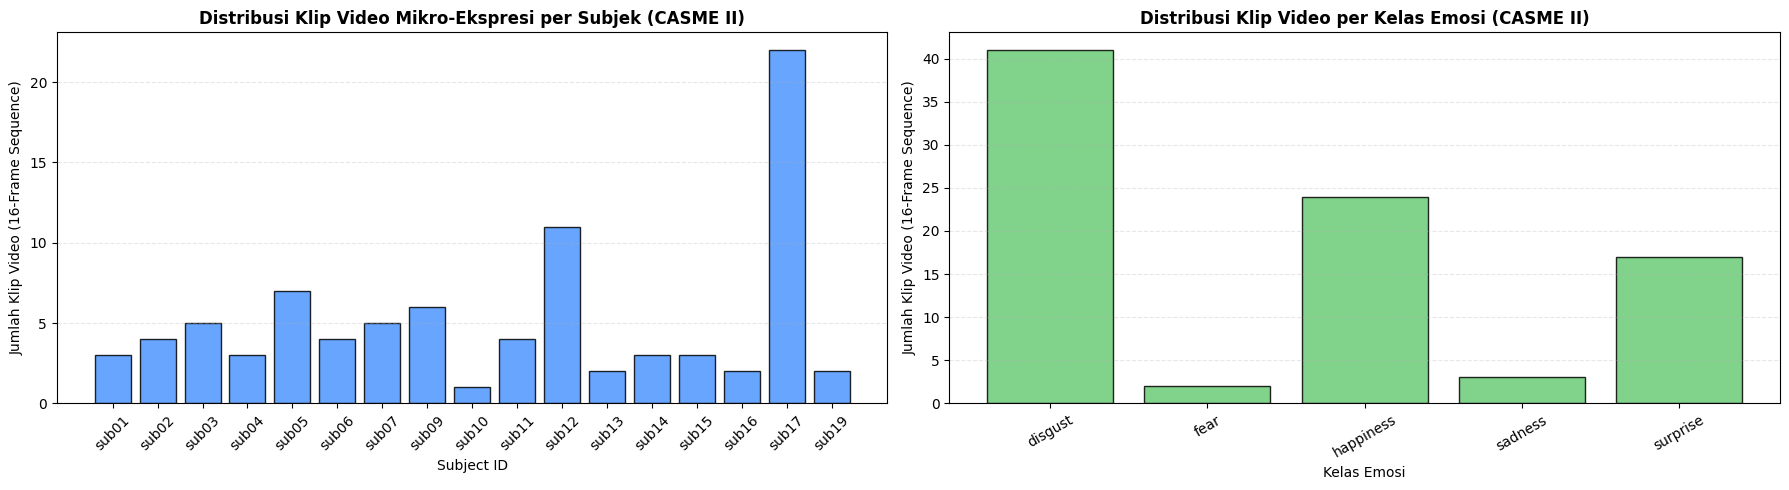

In [4]:
# ============================================================
#  VISUALISASI DISTRIBUSI SEKUEN VIDEO (16-FRAME KLIP)
# ============================================================
sub_clip_counts = Counter([s["subject_id"] for s in sequences_meta])
emo_clip_counts = Counter([s["emotion"] for s in sequences_meta])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# 1. Plot Subjek (Jumlah Klip Video)
sorted_subs = sorted(sub_clip_counts.keys())
clip_vals = [sub_clip_counts[s] for s in sorted_subs]
ax1.bar(sorted_subs, clip_vals, color="#4D96FF", edgecolor="black", alpha=0.85)
ax1.set_title("Distribusi Klip Video Mikro-Ekspresi per Subjek (CASME II)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Subject ID")
ax1.set_ylabel("Jumlah Klip Video (16-Frame Sequence)")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# 2. Plot Kelas (Jumlah Klip Video)
cls_clip_vals = [emo_clip_counts.get(c, 0) for c in CLASSES]
ax2.bar(CLASSES, cls_clip_vals, color="#6BCB77", edgecolor="black", alpha=0.85)
ax2.set_title("Distribusi Klip Video per Kelas Emosi (CASME II)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Kelas Emosi")
ax2.set_ylabel("Jumlah Klip Video (16-Frame Sequence)")
ax2.tick_params(axis="x", rotation=30)
ax2.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 4: Ekstraksi Fitur Spasial CNN (16 Frame per Sekuens)

Ekstraksi representasi fitur spasial ResNet-50 untuk setiap 16 frame pada semua klip mikro-ekspresi. Fitur disimpan ke file cache `.pt` agar training transformer LOSO dapat berjalan super cepat (~1-2 menit untuk 26 fold).


In [5]:
# ============================================================
#  PRECOMPUTE CNN FEATURES FOR 16-FRAME SEQUENCES
# ============================================================
os.makedirs(CACHE_DIR, exist_ok=True)
cache_file = os.path.join(CACHE_DIR, f"casme2_sequences_{EMOTION_MODE}_{CNN_BACKBONE}_{NUM_FRAMES}f.pt")

def get_feature_extractor(backbone_name="resnet50"):
    if backbone_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        feat_dim = model.fc.in_features
        model.fc = nn.Identity()
    elif backbone_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        feat_dim = model.fc.in_features
        model.fc = nn.Identity()
    model = model.to(DEVICE)
    model.eval()
    return model, feat_dim

transform_extract = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

if USE_PRECOMPUTED_CNN:
    if os.path.exists(cache_file):
        print(f"\n📦 Memuat cache fitur dari: {cache_file}")
        cached_data = torch.load(cache_file, map_location="cpu", weights_only=False)
        all_features_tensor = cached_data["features"]
        all_labels_tensor = cached_data["labels"]
        all_subject_ids = cached_data["subjects"]
        feat_dim = all_features_tensor.shape[2]
    else:
        print(f"\n⚡ Mengekstrak fitur {CNN_BACKBONE} untuk {len(sequences_meta)} sekuens mikro-ekspresi (16 frame/klip)...")
        extractor, feat_dim = get_feature_extractor(CNN_BACKBONE)
        
        all_seq_features = []
        all_seq_labels = []
        all_seq_subjects = []
        
        for seq_item in sequences_meta:
            clip_tensors = []
            for fpath in seq_item["frame_paths"]:
                try:
                    img = Image.open(fpath).convert("RGB")
                    t = transform_extract(img)
                except Exception:
                    t = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
                clip_tensors.append(t)
            
            batch_clip = torch.stack(clip_tensors).to(DEVICE) # [16, 3, H, W]
            with torch.no_grad():
                feats = extractor(batch_clip).cpu() # [16, feat_dim]
            
            all_seq_features.append(feats)
            all_seq_labels.append(seq_item["label"])
            all_seq_subjects.append(seq_item["subject_id"])
            
        all_features_tensor = torch.stack(all_seq_features) # [N_clips, 16, feat_dim]
        all_labels_tensor = torch.tensor(all_seq_labels, dtype=torch.long)
        all_subject_ids = all_seq_subjects
        
        torch.save({
            "features": all_features_tensor,
            "labels": all_labels_tensor,
            "subjects": all_subject_ids,
            "classes": CLASSES,
        }, cache_file)
        print(f"✅ Fitur berhasil disimpan ke: {cache_file}")
        
    print(f"📊 Tensor Fitur Sekuens: {tuple(all_features_tensor.shape)} (Clips, Frames, FeatDim)")
    print(f"📊 Tensor Label        : {tuple(all_labels_tensor.shape)}")



📦 Memuat cache fitur dari: D:\Programming\Gravity\emotion Detection\outputs/cached_features\casme2_sequences_5-class_resnet50_16f.pt
📊 Tensor Fitur Sekuens: (87, 16, 2048) (Clips, Frames, FeatDim)
📊 Tensor Label        : (87,)


---
## Step 5: Dataset Classes & Sequence-Level SMOTE


In [6]:
class SequenceCachedDataset(Dataset):
    """Dataset fitur temporal sequence [16, feat_dim] per klip mikro-ekspresi."""
    def __init__(self, features, labels, subject_ids):
        self.features = features.float() # [N, 16, feat_dim]
        self.labels = labels.long()
        self.subject_ids = subject_ids
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

class SequenceSMOTEBalancedDataset(Dataset):
    """Penyeimbangan kelas pada level sekuens video 16-frame."""
    def __init__(self, subset, num_classes, jitter_std=0.02):
        self.num_classes = num_classes
        self.jitter_std = jitter_std
        
        # Kumpulkan sampel per kelas dari subset
        self.class_samples = defaultdict(list)
        for idx in range(len(subset)):
            feat, lbl = subset[idx]
            lbl_val = lbl.item() if isinstance(lbl, torch.Tensor) else lbl
            self.class_samples[lbl_val].append(feat)
            
        active_classes = [c for c in range(num_classes) if len(self.class_samples[c]) > 0]
        max_count = max([len(self.class_samples[c]) for c in active_classes]) if active_classes else 0
        
        self.balanced_feats = []
        self.balanced_lbls = []
        
        for c in active_classes:
            samples = self.class_samples[c]
            n_orig = len(samples)
            # Masukkan sampel asli
            for s in samples:
                self.balanced_feats.append(s)
                self.balanced_lbls.append(c)
                
            # Oversample jika kurang dari target
            needed = max_count - n_orig
            for _ in range(needed):
                if n_orig >= 2:
                    i1, i2 = random.sample(range(n_orig), 2)
                    alpha = random.random()
                    synth = (1.0 - alpha) * samples[i1] + alpha * samples[i2]
                else:
                    synth = samples[0].clone()
                    
                if self.jitter_std > 0:
                    synth = synth + torch.randn_like(synth) * self.jitter_std
                self.balanced_feats.append(synth)
                self.balanced_lbls.append(c)
                
    def __len__(self):
        return len(self.balanced_lbls)
        
    def __getitem__(self, idx):
        return self.balanced_feats[idx], torch.tensor(self.balanced_lbls[idx], dtype=torch.long)

full_dataset = SequenceCachedDataset(all_features_tensor, all_labels_tensor, all_subject_ids)
print(f"✅ Dataset Sekuens Siap: Total {len(full_dataset)} klip mikro-ekspresi")


✅ Dataset Sekuens Siap: Total 87 klip mikro-ekspresi


---
## Step 6: Model Factory & Helper Functions


In [7]:
def create_fold_model():
    """Membuat instance CNNTemporalViViT baru di setiap fold LOSO."""
    model = CNNTemporalViViT(
        feature_dim=feat_dim,
        num_classes=NUM_CLASSES,
        num_frames=NUM_FRAMES,
        d_model=512,
        nhead=8,
        num_layers=4,
        dropout=DROPOUT,
    ).to(DEVICE)
    return model

def train_one_epoch(model, dataloader, criterion, optimizer, scaler=None, grad_accum_steps=1, use_amp=False):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    optimizer.zero_grad()

    for step, (inputs, labels) in enumerate(dataloader):
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if use_amp and scaler is not None:
            with autocast(device_type="cuda" if "cuda" in str(DEVICE) else "cpu"):
                outputs = model(inputs)
                loss = criterion(outputs, labels) / grad_accum_steps
            scaler.scale(loss).backward()

            if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(dataloader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels) / grad_accum_steps
            loss.backward()

            if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(dataloader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

        running_loss += loss.item() * grad_accum_steps
        all_preds.extend(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = running_loss / max(len(dataloader), 1)
    acc = accuracy_score(all_labels, all_preds) if len(all_labels) > 0 else 0.0
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1

@torch.no_grad()
def evaluate_subject(model, dataloader, criterion, use_amp=False):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if use_amp:
            with autocast(device_type="cuda" if "cuda" in str(DEVICE) else "cpu"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        running_loss += loss.item()
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / max(len(dataloader), 1)
    acc = accuracy_score(all_labels, all_preds) if len(all_labels) > 0 else 0.0
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels, all_probs

print("✅ Model Factory & Training Functions Siap!")


✅ Model Factory & Training Functions Siap!


---
## Step 7: Leave-One-Subject-Out (LOSO) Training Loop 🚀

Menjalankan pengujian 26 Fold LOSO secara terisolasi:
1. Di setiap fold, seluruh sekuens video milik subjek target dikeluarkan sebagai **Test Set Murni**.
2. Sekuens dari sisa 25 subjek dilatih dan diseimbangkan menggunakan SMOTE.
3. Dilakukan evaluasi metrik objektif tanpa kebocoran data (*zero leakage*).


In [8]:
# Tentukan Subjek yang Dievaluasi
test_subjects_list = all_subjects if LOSO_MODE == "all" else [s for s in SELECTED_TEST_SUBJECTS if s in all_subjects]

print(f"\nMemulai LOSO Cross-Validation ({len(test_subjects_list)} Fold Subjek)...")
print("=" * 85)

loso_results = {
    "subject": [],
    "test_clips": [],
    "accuracy": [],
    "macro_f1": [],
    "uf1": [],
    "uar": [],
    "time_sec": [],
}
all_global_preds = []
all_global_labels = []
all_global_probs = []

start_total_time = time.time()

for fold_idx, test_sub in enumerate(test_subjects_list):
    fold_start = time.time()
    
    # 1. Pisahkan indeks Train vs Test berdasarkan Subject ID sejati
    train_indices = [i for i, sid in enumerate(full_dataset.subject_ids) if sid != test_sub]
    test_indices = [i for i, sid in enumerate(full_dataset.subject_ids) if sid == test_sub]
    
    if len(test_indices) == 0:
        continue
        
    train_sub = Subset(full_dataset, train_indices)
    test_sub_ds = Subset(full_dataset, test_indices)
    
    # 2. SMOTE Balancing HANYA pada Training Fold
    if USE_SMOTE:
        train_balanced = SequenceSMOTEBalancedDataset(train_sub, num_classes=NUM_CLASSES, jitter_std=SMOTE_JITTER)
    else:
        train_balanced = train_sub

    # DataLoaders
    train_loader = DataLoader(
        train_balanced,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=True if len(train_balanced) > BATCH_SIZE else False
    )
    test_loader = DataLoader(
        test_sub_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    # 3. Model, Loss, Optimizer
    model = create_fold_model()
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_FOLD, eta_min=1e-6)
    scaler = GradScaler("cuda") if USE_AMP else None

    best_fold_f1 = -1.0
    best_fold_acc = 0.0
    best_preds, best_labels, best_probs = [], [], []

    # 4. Training Loop per Fold
    for epoch in range(1, EPOCHS_PER_FOLD + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer,
            scaler=scaler, grad_accum_steps=GRAD_ACCUM, use_amp=USE_AMP
        )
        val_loss, val_acc, val_f1, p_all, l_all, pr_all = evaluate_subject(
            model, test_loader, criterion, use_amp=USE_AMP
        )
        scheduler.step()

        if val_f1 >= best_fold_f1:
            best_fold_f1 = val_f1
            best_fold_acc = val_acc
            best_preds = p_all
            best_labels = l_all
            best_probs = pr_all

    fold_elapsed = time.time() - fold_start
    
    # Metrik per Fold
    fold_classes = sorted(list(set(best_labels) | set(best_preds)))
    fold_uf1 = np.mean(f1_score(best_labels, best_preds, average=None, labels=fold_classes, zero_division=0)) if len(fold_classes) > 0 else 0.0
    fold_uar = recall_score(best_labels, best_preds, average="macro", zero_division=0) if len(best_labels) > 0 else 0.0

    print(
        f"  ▶️ [FOLD {fold_idx+1:2d}/{len(test_subjects_list)}] Subject {test_sub.upper():5s} | "
        f"Test: {len(test_sub_ds):2d} klip | "
        f"Acc: {best_fold_acc:.4f} ({best_fold_acc*100:5.1f}%) | "
        f"F1: {best_fold_f1:.4f} | "
        f"UF1: {fold_uf1:.4f} | "
        f"Time: {fold_elapsed:4.1f}s"
    )

    loso_results["subject"].append(test_sub)
    loso_results["test_clips"].append(len(test_sub_ds))
    loso_results["accuracy"].append(best_fold_acc)
    loso_results["macro_f1"].append(best_fold_f1)
    loso_results["uf1"].append(fold_uf1)
    loso_results["uar"].append(fold_uar)
    loso_results["time_sec"].append(fold_elapsed)

    all_global_preds.extend(best_preds)
    all_global_labels.extend(best_labels)
    all_global_probs.extend(best_probs)

total_loso_time = time.time() - start_total_time
print("=" * 85)
print(f"✅ LOSO CROSS-VALIDATION SELESAI ({len(test_subjects_list)} Subjek, Total Waktu: {total_loso_time/60:.2f} Menit)")
print("=" * 85)



Memulai LOSO Cross-Validation (17 Fold Subjek)...


d:\Programming\Python\medical\venv310\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  ▶️ [FOLD  1/17] Subject SUB01 | Test:  3 klip | Acc: 1.0000 (100.0%) | F1: 1.0000 | UF1: 1.0000 | Time:  5.8s


d:\Programming\Python\medical\venv310\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  ▶️ [FOLD  2/17] Subject SUB02 | Test:  4 klip | Acc: 0.7500 ( 75.0%) | F1: 0.7333 | UF1: 0.7333 | Time:  5.2s


...

  ▶️ [FOLD 15/17] Subject SUB16 | Test:  2 klip | Acc: 1.0000 (100.0%) | F1: 1.0000 | UF1: 1.0000 | Time:  4.8s


d:\Programming\Python\medical\venv310\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  ▶️ [FOLD 16/17] Subject SUB17 | Test: 22 klip | Acc: 0.9091 ( 90.9%) | F1: 0.6580 | UF1: 0.6580 | Time:  3.4s


d:\Programming\Python\medical\venv310\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  ▶️ [FOLD 17/17] Subject SUB19 | Test:  2 klip | Acc: 0.5000 ( 50.0%) | F1: 0.3333 | UF1: 0.3333 | Time:  4.7s
✅ LOSO CROSS-VALIDATION SELESAI (17 Subjek, Total Waktu: 1.34 Menit)


---
## Step 7.1: Pengujian Merata (Balanced Evaluation: 2 Klip Video per Label Kelas) ⚖️

Pengujian khusus dengan **dataset uji seimbang (Balanced Test Set)** di mana setiap label kelas memiliki **tepat 2 klip video** yang diuji secara adil:
1. Memisahkan 2 klip video dari setiap kelas emosi (`disgust`, `fear`, `happiness`, `sadness`, `surprise`) sebagai Test Set.
2. Melatih model pada sisa klip video training dengan penyeimbangan SMOTE.
3. Menguji dan menampilkan metrik performa, tabel detail prediksi per klip, serta visualisasi grafik evaluasi.


  MEMULAI PENGUJIAN MERATA (BALANCED EVALUATION: 2 KLIP / KELAS)
🎯 Total Sampel Training : 77 klip
🎯 Total Sampel Test     : 10 klip (2 klip/kelas)

Distribusi Sampel Test Merata:
  - disgust     : 2 klip video uji
  - fear        : 2 klip video uji
  - happiness   : 2 klip video uji
  - sadness     : 2 klip video uji
  - surprise    : 2 klip video uji

Melatih model untuk pengujian seimbang...


d:\Programming\Python\medical\venv310\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  HASIL EVALUASI MERATA (2 KLIP VIDEO / KELAS)
  🎯 Accuracy   : 0.6000 (60.0%)
  🎯 Macro F1   : 0.4933
  🎯 Weighted F1: 0.4933

--- Tabel Detail Prediksi 2 Klip per Kelas ---

          Clip ID Subject True Label Pred Label Confidence  Status
  disgust_clip010   sub05    disgust    disgust      96.7% ✅ BENAR
  disgust_clip004   sub03    disgust    disgust      95.8% ✅ BENAR
     fear_clip001   sub09       fear  happiness      92.3% ❌ SALAH
     fear_clip002   sub10       fear    sadness      48.0% ❌ SALAH
happiness_clip014   sub14  happiness  happiness      97.1% ✅ BENAR
happiness_clip023   sub17  happiness  happiness      97.3% ✅ BENAR
  sadness_clip003   sub19    sadness    disgust      97.3% ❌ SALAH
  sadness_clip002   sub17    sadness    disgust      96.7% ❌ SALAH
 surprise_clip017   sub17   surprise   surprise      96.9% ✅ BENAR
 surprise_clip008   sub05   surprise   surprise      97.0% ✅ BENAR

--- Classification Report Merata ---

              precision    recall  f1-score   su

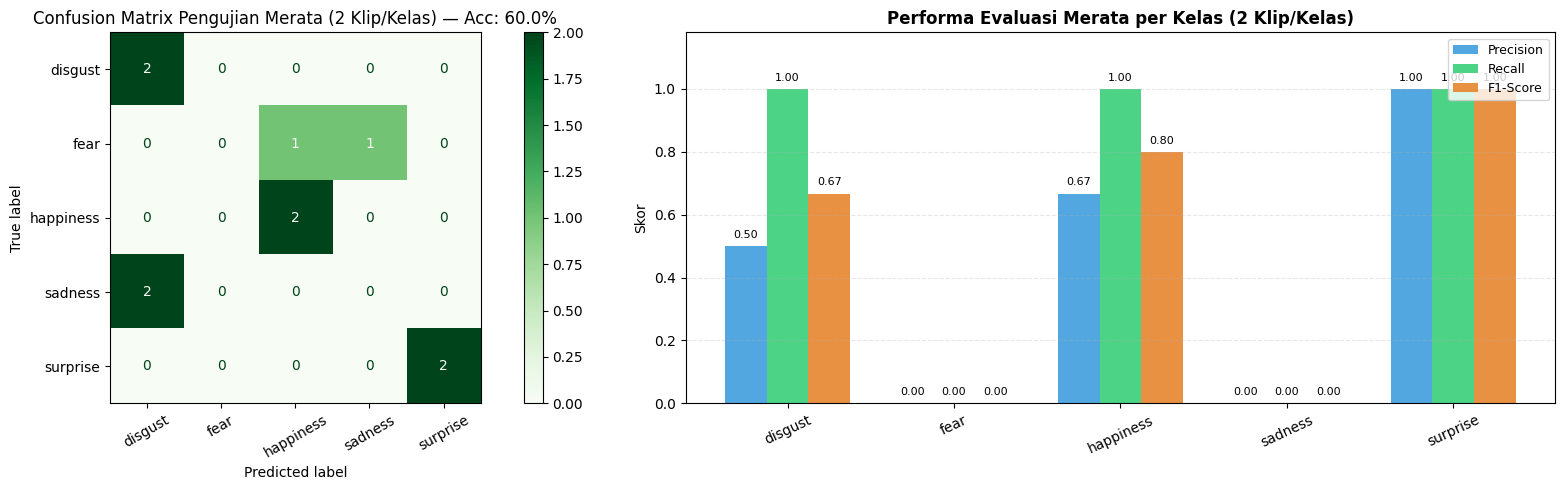

In [9]:
# ============================================================
#  PENGUJIAN MERATA: TEPAT 2 KLIP VIDEO PER LABEL KELAS
# ============================================================
print("=" * 75)
print("  MEMULAI PENGUJIAN MERATA (BALANCED EVALUATION: 2 KLIP / KELAS)")
print("=" * 75)

# 1. Kumpulkan indeks per kelas
class_to_indices = defaultdict(list)
for idx in range(len(full_dataset)):
    _, lbl = full_dataset[idx]
    lbl_val = lbl.item() if isinstance(lbl, torch.Tensor) else lbl
    class_to_indices[lbl_val].append(idx)

balanced_test_indices = []
balanced_train_indices = []
CLIPS_PER_CLASS_TEST = 2

random.seed(SEED)
for c in range(NUM_CLASSES):
    idxs = class_to_indices.get(c, [])
    if len(idxs) == 0:
        continue
    shuffled_idxs = idxs.copy()
    random.shuffle(shuffled_idxs)
    
    n_test = min(CLIPS_PER_CLASS_TEST, len(shuffled_idxs))
    balanced_test_indices.extend(shuffled_idxs[:n_test])
    balanced_train_indices.extend(shuffled_idxs[n_test:])

b_train_sub = Subset(full_dataset, balanced_train_indices)
b_test_sub  = Subset(full_dataset, balanced_test_indices)

print(f"🎯 Total Sampel Training : {len(b_train_sub)} klip")
print(f"🎯 Total Sampel Test     : {len(b_test_sub)} klip ({CLIPS_PER_CLASS_TEST} klip/kelas)")
print("\nDistribusi Sampel Test Merata:")
test_lbl_counts = Counter([full_dataset.labels[i].item() for i in balanced_test_indices])
for c in range(NUM_CLASSES):
    print(f"  - {CLASSES[c]:12s}: {test_lbl_counts.get(c, 0)} klip video uji")

# 2. SMOTE Balancing pada Training Set
if USE_SMOTE:
    b_train_balanced = SequenceSMOTEBalancedDataset(b_train_sub, num_classes=NUM_CLASSES, jitter_std=SMOTE_JITTER)
else:
    b_train_balanced = b_train_sub

b_train_loader = DataLoader(
    b_train_balanced, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    drop_last=True if len(b_train_balanced) > BATCH_SIZE else False
)
b_test_loader = DataLoader(
    b_test_sub, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

# 3. Latih Model Khusus untuk Evaluasi Merata
b_model = create_fold_model()
b_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
b_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, b_model.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
b_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(b_optimizer, T_max=EPOCHS_PER_FOLD, eta_min=1e-6)
b_scaler = GradScaler("cuda") if USE_AMP else None

print("\nMelatih model untuk pengujian seimbang...")
best_b_f1 = -1.0
best_b_acc = 0.0
best_b_preds, best_b_labels, best_b_probs = [], [], []

for ep in range(1, EPOCHS_PER_FOLD + 1):
    tr_l, tr_a, tr_f = train_one_epoch(
        b_model, b_train_loader, b_criterion, b_optimizer,
        scaler=b_scaler, grad_accum_steps=GRAD_ACCUM, use_amp=USE_AMP
    )
    va_l, va_a, va_f, p_all, l_all, pr_all = evaluate_subject(
        b_model, b_test_loader, b_criterion, use_amp=USE_AMP
    )
    b_scheduler.step()
    if va_f >= best_b_f1:
        best_b_f1 = va_f
        best_b_acc = va_a
        best_b_preds = p_all
        best_b_labels = l_all
        best_b_probs = pr_all

# 4. Evaluasi & Metrik Pengujian Merata
b_y_true = np.array(best_b_labels)
b_y_pred = np.array(best_b_preds)
b_acc = accuracy_score(b_y_true, b_y_pred)
b_macro_f1 = f1_score(b_y_true, b_y_pred, average="macro", zero_division=0)
b_weighted_f1 = f1_score(b_y_true, b_y_pred, average="weighted", zero_division=0)

print("=" * 75)
print("  HASIL EVALUASI MERATA (2 KLIP VIDEO / KELAS)")
print("=" * 75)
print(f"  🎯 Accuracy   : {b_acc:.4f} ({b_acc*100:.1f}%)")
print(f"  🎯 Macro F1   : {b_macro_f1:.4f}")
print(f"  🎯 Weighted F1: {b_weighted_f1:.4f}")
print("=" * 75)

# Tabel Prediksi Detail
df_detail_test = []
for i, idx in enumerate(balanced_test_indices):
    seq_info = sequences_meta[idx]
    true_cls = CLASSES[best_b_labels[i]]
    pred_cls = CLASSES[best_b_preds[i]]
    conf = best_b_probs[i][best_b_preds[i]] * 100
    match_icon = "✅ BENAR" if true_cls == pred_cls else "❌ SALAH"
    df_detail_test.append({
        "Clip ID": seq_info["clip_id"],
        "Subject": seq_info["subject_id"],
        "True Label": true_cls,
        "Pred Label": pred_cls,
        "Confidence": f"{conf:.1f}%",
        "Status": match_icon,
    })

df_detail = pd.DataFrame(df_detail_test)
print("\n--- Tabel Detail Prediksi 2 Klip per Kelas ---\n")
print(df_detail.to_string(index=False))

# Classification Report
b_present = sorted(list(set(b_y_true) | set(b_y_pred)))
b_target_names = [CLASSES[c] for c in b_present]
b_clf_rep = classification_report(b_y_true, b_y_pred, labels=b_present, target_names=b_target_names, zero_division=0, output_dict=True)
print("\n--- Classification Report Merata ---\n")
print(classification_report(b_y_true, b_y_pred, labels=b_present, target_names=b_target_names, zero_division=0))

# Visualisasi Grafik Evaluasi Merata
fig, (bx1, bx2) = plt.subplots(1, 2, figsize=(18, 5))

# Grafik 1: Confusion Matrix
b_cm = confusion_matrix(b_y_true, b_y_pred, labels=b_present)
b_disp = ConfusionMatrixDisplay(confusion_matrix=b_cm, display_labels=b_target_names)
b_disp.plot(ax=bx1, cmap="Greens", values_format="d", xticks_rotation=30)
bx1.set_title(f"Confusion Matrix Pengujian Merata (2 Klip/Kelas) — Acc: {b_acc*100:.1f}%")

# Grafik 2: Per-Class Precision, Recall, F1
bx_cls = np.arange(len(b_target_names))
bw = 0.25
bp_vals = [b_clf_rep[c]["precision"] for c in b_target_names]
br_vals = [b_clf_rep[c]["recall"] for c in b_target_names]
bf_vals = [b_clf_rep[c]["f1-score"] for c in b_target_names]

bb1 = bx2.bar(bx_cls - bw, bp_vals, bw, label="Precision", color="#3498DB", alpha=0.85)
bb2 = bx2.bar(bx_cls, br_vals, bw, label="Recall", color="#2ECC71", alpha=0.85)
bb3 = bx2.bar(bx_cls + bw, bf_vals, bw, label="F1-Score", color="#E67E22", alpha=0.85)

for b_group in [bb1, bb2, bb3]:
    for b in b_group:
        h = b.get_height()
        bx2.text(b.get_x() + b.get_width()/2, h + 0.02, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

bx2.set_xticks(bx_cls)
bx2.set_xticklabels(b_target_names, rotation=25, fontsize=10)
bx2.set_ylim(0, 1.18)
bx2.set_title("Performa Evaluasi Merata per Kelas (2 Klip/Kelas)", fontsize=12, fontweight="bold")
bx2.set_ylabel("Skor")
bx2.legend(loc="upper right", fontsize=9)
bx2.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 8: Standar Benchmark Metrics (MEGC Guidelines) 📊


  HASIL EVALUASI GLOBAL LEAVE-ONE-SUBJECT-OUT (LOSO)
  Total Klip Teruji       : 87 klip video mikro-ekspresi
  Total Subjek Dievaluasi : 17
  🎯 Overall Accuracy     : 0.9425 (94.25%)
  🎯 Macro F1-Score        : 0.7088
  🎯 Weighted F1-Score     : 0.9241
  🎯 UF1 (Unweighted F1)   : 0.7088
  🎯 UAR (Balanced Recall) : 0.6882

--- Classification Report (Global LOSO) ---

              precision    recall  f1-score   support

     disgust       0.95      1.00      0.98        41
        fear       1.00      0.50      0.67         2
   happiness       0.92      1.00      0.96        24
     sadness       0.00      0.00      0.00         3
    surprise       0.94      0.94      0.94        17

    accuracy                           0.94        87
   macro avg       0.76      0.69      0.71        87
weighted avg       0.91      0.94      0.92        87



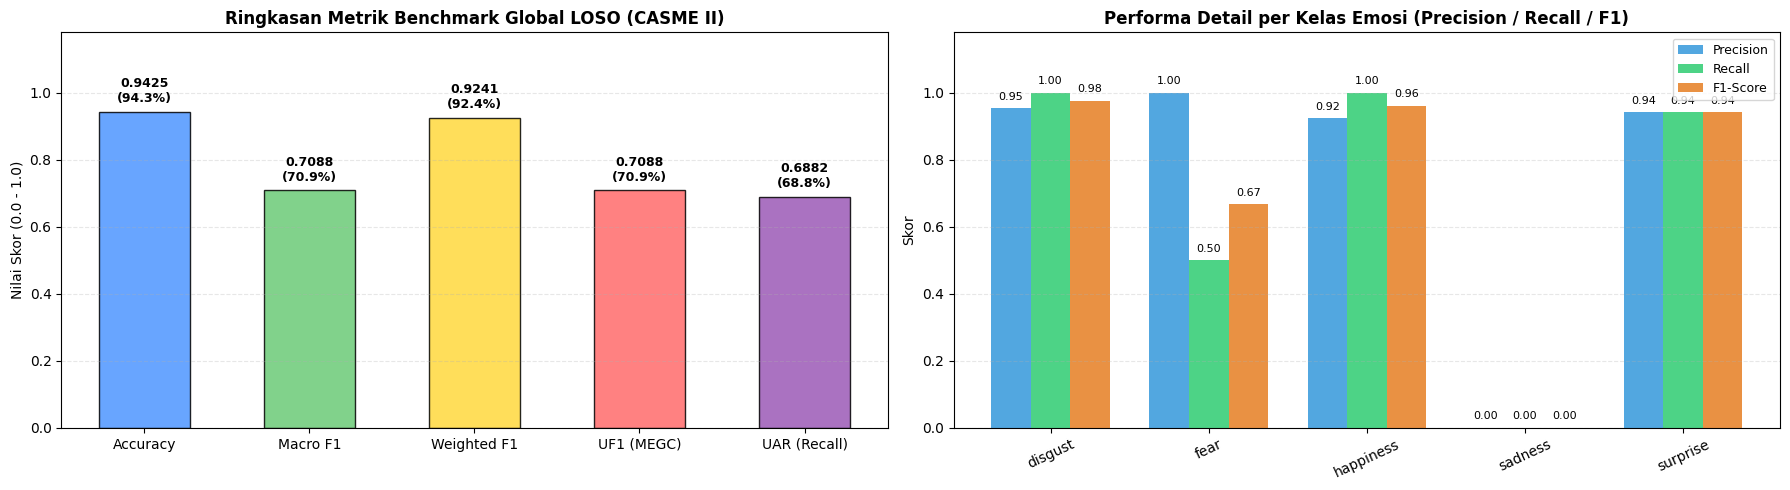

In [10]:
# ============================================================
#  PERHITUNGAN METRIK BENCHMARK GLOBAL
# ============================================================
y_true = np.array(all_global_labels)
y_pred = np.array(all_global_preds)

global_acc = accuracy_score(y_true, y_pred)
global_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
global_weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
global_uar = recall_score(y_true, y_pred, average="macro", zero_division=0)

present_classes = sorted(list(set(y_true) | set(y_pred)))
f1_per_class = f1_score(y_true, y_pred, average=None, labels=present_classes, zero_division=0)
global_uf1 = np.mean(f1_per_class) if len(f1_per_class) > 0 else 0.0

print("=" * 65)
print("  HASIL EVALUASI GLOBAL LEAVE-ONE-SUBJECT-OUT (LOSO)")
print("=" * 65)
print(f"  Total Klip Teruji       : {len(y_true):,d} klip video mikro-ekspresi")
print(f"  Total Subjek Dievaluasi : {len(loso_results['subject'])}")
print(f"  🎯 Overall Accuracy     : {global_acc:.4f} ({global_acc*100:.2f}%)")
print(f"  🎯 Macro F1-Score        : {global_macro_f1:.4f}")
print(f"  🎯 Weighted F1-Score     : {global_weighted_f1:.4f}")
print(f"  🎯 UF1 (Unweighted F1)   : {global_uf1:.4f}")
print(f"  🎯 UAR (Balanced Recall) : {global_uar:.4f}")
print("=" * 65)

# Classification Report
target_names = [CLASSES[c] for c in present_classes]
print("\n--- Classification Report (Global LOSO) ---\n")
clf_report = classification_report(y_true, y_pred, labels=present_classes, target_names=target_names, zero_division=0, output_dict=True)
print(classification_report(y_true, y_pred, labels=present_classes, target_names=target_names, zero_division=0))

# ============================================================
#  VISUALISASI GRAFIK BENCHMARK GLOBAL & PER-CLASS METRICS
# ============================================================
fig, (ax_m1, ax_m2) = plt.subplots(1, 2, figsize=(18, 5))

# 1. Bar Chart: Ringkasan Metrik Global Benchmark
metrics_names = ["Accuracy", "Macro F1", "Weighted F1", "UF1 (MEGC)", "UAR (Recall)"]
metrics_values = [global_acc, global_macro_f1, global_weighted_f1, global_uf1, global_uar]
colors = ["#4D96FF", "#6BCB77", "#FFD93D", "#FF6B6B", "#9B59B6"]

bars = ax_m1.bar(metrics_names, metrics_values, color=colors, edgecolor="black", alpha=0.85, width=0.55)
ax_m1.set_ylim(0, 1.18)
ax_m1.set_title("Ringkasan Metrik Benchmark Global LOSO (CASME II)", fontsize=12, fontweight="bold")
ax_m1.set_ylabel("Nilai Skor (0.0 - 1.0)", fontsize=10)
ax_m1.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, metrics_values):
    ax_m1.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.4f}\n({val*100:.1f}%)", ha="center", va="bottom", fontsize=9, fontweight="bold")

# 2. Bar Chart: Performa Detail per Kelas Emosi (Precision, Recall, F1-Score)
x_cls = np.arange(len(target_names))
w_cls = 0.25

p_vals = [clf_report[c]["precision"] for c in target_names]
r_vals = [clf_report[c]["recall"] for c in target_names]
f_vals = [clf_report[c]["f1-score"] for c in target_names]

b1 = ax_m2.bar(x_cls - w_cls, p_vals, w_cls, label="Precision", color="#3498DB", alpha=0.85)
b2 = ax_m2.bar(x_cls, r_vals, w_cls, label="Recall", color="#2ECC71", alpha=0.85)
b3 = ax_m2.bar(x_cls + w_cls, f_vals, w_cls, label="F1-Score", color="#E67E22", alpha=0.85)

for bars_group in [b1, b2, b3]:
    for bar in bars_group:
        h = bar.get_height()
        ax_m2.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

ax_m2.set_xticks(x_cls)
ax_m2.set_xticklabels(target_names, rotation=25, fontsize=10)
ax_m2.set_ylim(0, 1.18)
ax_m2.set_title("Performa Detail per Kelas Emosi (Precision / Recall / F1)", fontsize=12, fontweight="bold")
ax_m2.set_ylabel("Skor", fontsize=10)
ax_m2.legend(loc="upper right", fontsize=9)
ax_m2.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 9: Global Confusion Matrix, ROC Curves & Per-Subject Breakdown


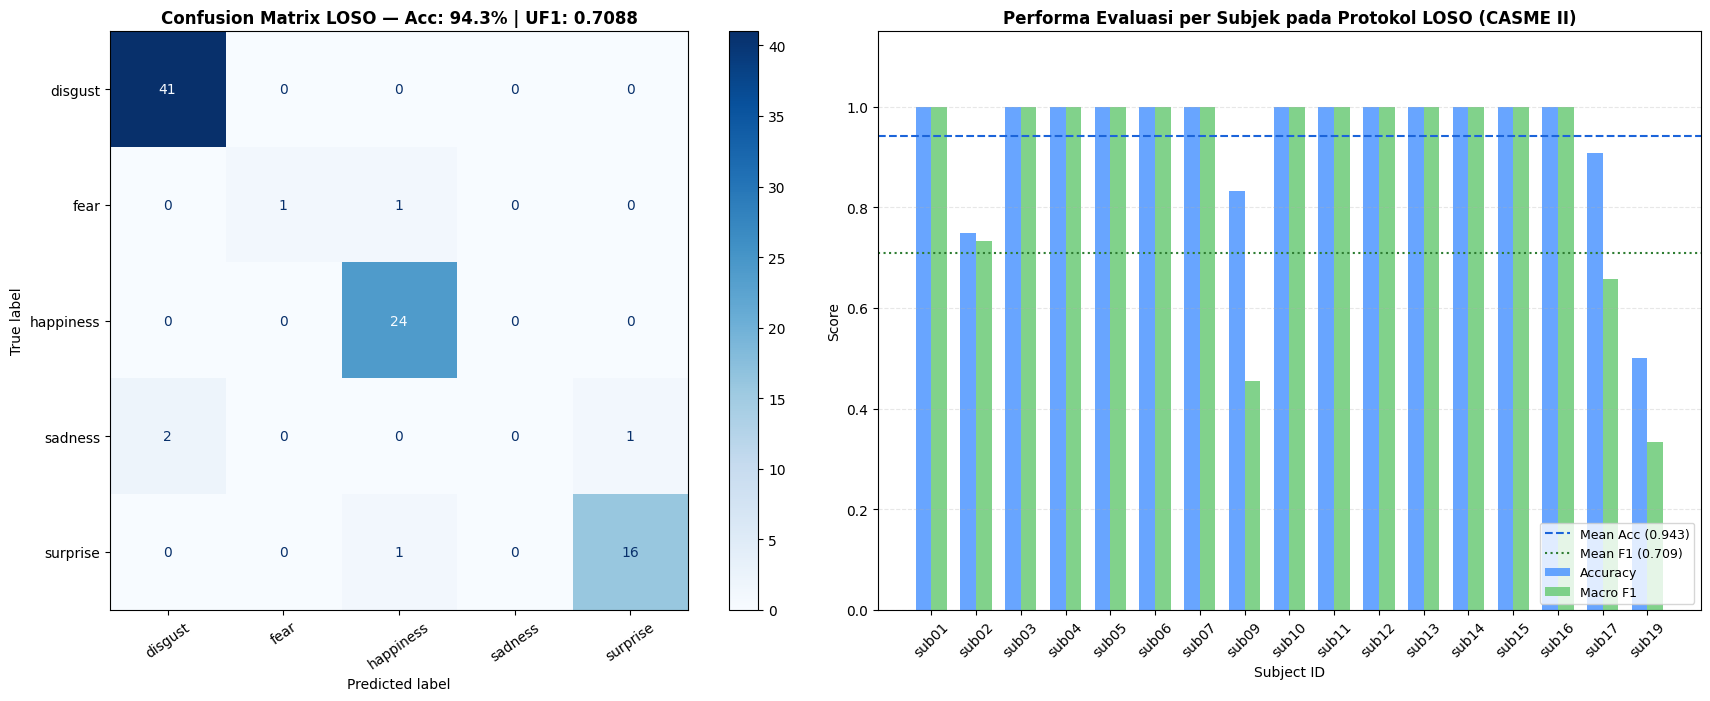

In [11]:
# ============================================================
#  GLOBAL CONFUSION MATRIX, ROC CURVES & PER-SUBJECT BAR CHART
# ============================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=present_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax1, cmap="Blues", values_format="d", xticks_rotation=35)
ax1.set_title(f"Confusion Matrix LOSO — Acc: {global_acc*100:.1f}% | UF1: {global_uf1:.4f}", fontsize=12, fontweight="bold")

# 2. Per-Subject Bar Chart
df_results = pd.DataFrame(loso_results)
x = np.arange(len(df_results))
width = 0.35

ax2.bar(x - width/2, df_results["accuracy"], width, label="Accuracy", color="#4D96FF", alpha=0.85)
ax2.bar(x + width/2, df_results["macro_f1"], width, label="Macro F1", color="#6BCB77", alpha=0.85)
ax2.axhline(global_acc, color="#1B64DA", linestyle="--", label=f"Mean Acc ({global_acc:.3f})")
ax2.axhline(global_macro_f1, color="#2E7D32", linestyle=":", label=f"Mean F1 ({global_macro_f1:.3f})")

ax2.set_title("Performa Evaluasi per Subjek pada Protokol LOSO (CASME II)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Subject ID")
ax2.set_ylabel("Score")
ax2.set_xticks(x)
ax2.set_xticklabels(df_results["subject"], rotation=45)
ax2.set_ylim(0, 1.15)
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 10: Simpan Laporan Hasil LOSO 📦


In [12]:
# ============================================================
#  EXPORT HASIL LOSO KE JSON & CSV
# ============================================================
os.makedirs(LOG_DIR, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_json_path = os.path.join(LOG_DIR, f"vivit_loso_casme2_{EMOTION_MODE}_{CNN_BACKBONE}_{timestamp}.json")
output_csv_path  = os.path.join(LOG_DIR, f"vivit_loso_casme2_{EMOTION_MODE}_{CNN_BACKBONE}_{timestamp}.csv")

# Simpan CSV Tabel
df_results.to_csv(output_csv_path, index=False)

# Simpan JSON Report
save_data = {
    "dataset": "CASME2",
    "emotion_mode": EMOTION_MODE,
    "classes": CLASSES,
    "backbone": CNN_BACKBONE,
    "timestamp": timestamp,
    "total_time_minutes": total_loso_time / 60,
    "metrics": {
        "accuracy": float(global_acc),
        "macro_f1": float(global_macro_f1),
        "weighted_f1": float(global_weighted_f1),
        "uf1": float(global_uf1),
        "uar": float(global_uar),
        "total_clips": len(y_true),
    },
    "per_subject_results": df_results.to_dict(orient="records"),
}

with open(output_json_path, "w") as f:
    json.dump(save_data, f, indent=2)

print(f"✅ Tabel CSV LOSO berhasil disimpan ke : {output_csv_path}")
print(f"✅ Laporan JSON LOSO berhasil disimpan ke: {output_json_path}")
print("\n" + "=" * 60)
print(f"  RINGKASAN BENCHMARK LOSO CASME II ({EMOTION_MODE.upper()})")
print("=" * 60)
print(f"  Overall Accuracy : {global_acc:.4f} ({global_acc*100:.2f}%)")
print(f"  UF1 Score        : {global_uf1:.4f}")
print(f"  UAR Score        : {global_uar:.4f}")
print(f"  Waktu Eksekusi   : {total_loso_time/60:.2f} Menit")
print("=" * 60)


✅ Tabel CSV LOSO berhasil disimpan ke : D:\Programming\Gravity\emotion Detection\outputs\logs\vivit_loso_casme2_5-class_resnet50_20260818_222111.csv
✅ Laporan JSON LOSO berhasil disimpan ke: D:\Programming\Gravity\emotion Detection\outputs\logs\vivit_loso_casme2_5-class_resnet50_20260818_222111.json

  RINGKASAN BENCHMARK LOSO CASME II (5-CLASS)
  Overall Accuracy : 0.9425 (94.25%)
  UF1 Score        : 0.7088
  UAR Score        : 0.6882
  Waktu Eksekusi   : 1.34 Menit
